# arXiv Topic Clustering

Unsupervised Machine Learning homework project for `VEMISAM255N/2025/26/2`.

The goal is to build a small research tool around recent machine learning and natural language processing papers from arXiv. The dominant task is unsupervised clustering: I will compare multiple clustering algorithms and document representations, then use the resulting topic structure for exploration and content-based paper recommendation.

## Block 1 - Data Acquisition

This block collects recent arXiv papers from `cs.LG` and `cs.CL`, restricted to the last 12 months. The fetched metadata is normalized into a tabular format and cached as parquet so later notebook runs do not need to query the live API again.

For the first implementation pass, the target dataset size is intentionally modest: roughly 2,000 papers. That is large enough for meaningful clustering while keeping API fetching and later embedding computation manageable for a time-sensitive homework workflow. To keep the later time-based analysis meaningful, the sample is fetched in monthly windows rather than taking only the newest 2,000 papers.

In [1]:
from __future__ import annotations

import math
from datetime import datetime, timedelta, timezone
from pathlib import Path

import arxiv
import pandas as pd

pd.set_option("display.max_colwidth", 120)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

PAPERS_CACHE = DATA_DIR / "arxiv_papers_12mo_2000.parquet"
CATEGORIES = ["cs.LG", "cs.CL"]
TARGET_PAPERS = 2_000
LOOKBACK_DAYS = 365

END_DATE = datetime.now(timezone.utc)
START_DATE = END_DATE - timedelta(days=LOOKBACK_DAYS)

START_DATE.date(), END_DATE.date()

(datetime.date(2025, 5, 3), datetime.date(2026, 5, 3))

In [2]:
def arxiv_date(dt: datetime) -> str:
    """Format a datetime for arXiv's submittedDate search field."""
    return dt.strftime("%Y%m%d%H%M")


def build_query(categories: list[str], start_date: datetime, end_date: datetime) -> str:
    category_query = " OR ".join(f"cat:{category}" for category in categories)
    date_query = f"submittedDate:[{arxiv_date(start_date)} TO {arxiv_date(end_date)}]"
    return f"({category_query}) AND {date_query}"


def month_windows(start_date: datetime, end_date: datetime) -> list[tuple[datetime, datetime]]:
    starts = pd.date_range(
        start=start_date.date().replace(day=1),
        end=end_date.date(),
        freq="MS",
        tz="UTC",
    ).to_pydatetime()
    windows = []
    for window_start in starts:
        next_month = window_start + pd.DateOffset(months=1)
        clipped_start = max(window_start, start_date)
        clipped_end = min(next_month.to_pydatetime(), end_date)
        if clipped_start < clipped_end:
            windows.append((clipped_start, clipped_end))
    return windows


def paper_to_record(result: arxiv.Result) -> dict[str, object]:
    return {
        "arxiv_id": result.get_short_id(),
        "entry_id": result.entry_id,
        "title": " ".join(result.title.split()),
        "abstract": " ".join(result.summary.split()),
        "primary_category": result.primary_category,
        "categories": list(result.categories),
        "published": result.published,
        "updated": result.updated,
        "authors": [author.name for author in result.authors],
        "pdf_url": result.pdf_url,
    }


def fetch_arxiv_window(
    categories: list[str],
    start_date: datetime,
    end_date: datetime,
    max_results: int,
) -> pd.DataFrame:
    query = build_query(categories, start_date, end_date)
    search = arxiv.Search(
        query=query,
        max_results=max_results,
        sort_by=arxiv.SortCriterion.SubmittedDate,
        sort_order=arxiv.SortOrder.Descending,
    )
    client = arxiv.Client(page_size=100, delay_seconds=3, num_retries=5)

    records = [paper_to_record(result) for result in client.results(search)]
    return pd.DataFrame.from_records(records)


def fetch_arxiv_papers(
    categories: list[str],
    start_date: datetime,
    end_date: datetime,
    max_results: int,
) -> pd.DataFrame:
    windows = month_windows(start_date, end_date)
    max_per_window = math.ceil(max_results / len(windows))

    monthly_frames = []
    for window_start, window_end in windows:
        frame = fetch_arxiv_window(categories, window_start, window_end, max_per_window)
        print(f"{window_start:%Y-%m}: fetched {len(frame):>3} papers")
        monthly_frames.append(frame)

    papers = pd.concat(monthly_frames, ignore_index=True)
    if papers.empty:
        raise RuntimeError("The arXiv query returned no papers. Check API access and query syntax.")

    papers = (
        papers.drop_duplicates(subset="arxiv_id")
        .sort_values("published", ascending=False)
        .reset_index(drop=True)
    )
    papers["published_month"] = papers["published"].dt.to_period("M").astype(str)
    papers["abstract_length"] = papers["abstract"].str.split().str.len()
    return papers.head(max_results)


windows = month_windows(START_DATE, END_DATE)
query = build_query(CATEGORIES, windows[0][0], windows[0][1])
len(windows), query

(13,
 '(cat:cs.LG OR cat:cs.CL) AND submittedDate:[202505032049 TO 202506010000]')

In [3]:
if PAPERS_CACHE.exists():
    papers = pd.read_parquet(PAPERS_CACHE)
    source = "cache"
else:
    papers = fetch_arxiv_papers(CATEGORIES, START_DATE, END_DATE, TARGET_PAPERS)
    papers.to_parquet(PAPERS_CACHE, index=False)
    source = "arXiv API"

print(f"Loaded {len(papers):,} papers from {source}.")
print(f"Cache path: {PAPERS_CACHE}")
papers.head(3)

Loaded 1,848 papers from cache.
Cache path: data/arxiv_papers_12mo_2000.parquet


,arxiv_id,entry_id,title,abstract,primary_category,categories,published,updated,authors,pdf_url,published_month,abstract_length
0,2604.28186v1,http://arxiv.org/abs/2604.28186v1,Computing Equilibrium beyond Unilateral Deviation,"Most familiar equilibrium concepts, such as Nash and correlated equilibrium, guarantee only that no single player ca...",cs.GT,"[cs.GT, cs.AI, cs.CC, cs.LG, econ.TH]",2026-04-30 17:59:07+00:00,2026-04-30 17:59:07+00:00,"[Mingyang Liu, Gabriele Farina, Asuman Ozdaglar]",https://arxiv.org/pdf/2604.28186v1,2026-04,170
1,2604.28182v1,http://arxiv.org/abs/2604.28182v1,Exploration Hacking: Can LLMs Learn to Resist RL Training?,"Reinforcement learning (RL) has become essential to the post-training of large language models (LLMs) for reasoning,...",cs.LG,"[cs.LG, cs.CL]",2026-04-30 17:58:39+00:00,2026-04-30 17:58:39+00:00,"[Eyon Jang, Damon Falck, Joschka Braun, Nathalie Kirch, Achu Menon, Perusha Moodley, Scott Emmons, Roland S. Zimmerm...",https://arxiv.org/pdf/2604.28182v1,2026-04,176
2,2604.28181v1,http://arxiv.org/abs/2604.28181v1,Synthetic Computers at Scale for Long-Horizon Productivity Simulation,"Realistic long-horizon productivity work is strongly conditioned on user-specific computer environments, where much ...",cs.AI,"[cs.AI, cs.CL, cs.LG]",2026-04-30 17:58:02+00:00,2026-04-30 17:58:02+00:00,"[Tao Ge, Baolin Peng, Hao Cheng, Jianfeng Gao]",https://arxiv.org/pdf/2604.28181v1,2026-04,251


In [4]:
summary = {
    "papers": len(papers),
    "date_min": papers["published"].min().date(),
    "date_max": papers["published"].max().date(),
    "primary_categories": papers["primary_category"].value_counts().to_dict(),
    "median_abstract_words": int(papers["abstract_length"].median()),
}
summary

{'papers': 1848,
 'date_min': datetime.date(2025, 5, 31),
 'date_max': datetime.date(2026, 4, 30),
 'primary_categories': {'cs.LG': 776,
  'cs.CL': 459,
  'cs.AI': 114,
  'cs.CV': 98,
  'stat.ML': 53,
  'cs.CR': 36,
  'cs.RO': 25,
  'cs.IR': 24,
  'cs.SE': 21,
  'cs.SD': 19,
  'quant-ph': 18,
  'eess.SY': 14,
  'eess.SP': 13,
  'eess.IV': 11,
  'math.OC': 11,
  'cs.NE': 9,
  'cond-mat.mtrl-sci': 9,
  'cs.HC': 9,
  'cs.DC': 8,
  'cs.NI': 8,
  'eess.AS': 7,
  'stat.ME': 6,
  'q-bio.NC': 5,
  'cs.MA': 5,
  'math.NA': 4,
  'math.ST': 3,
  'cs.IT': 3,
  'cond-mat.dis-nn': 3,
  'cs.LO': 3,
  'cs.AR': 3,
  'physics.med-ph': 3,
  'cs.CY': 3,
  'q-fin.RM': 3,
  'q-fin.ST': 3,
  'physics.ao-ph': 3,
  'cs.DS': 3,
  'cs.CE': 3,
  'cs.GR': 3,
  'cs.GT': 2,
  'physics.soc-ph': 2,
  'q-bio.GN': 2,
  'cs.ET': 2,
  'physics.geo-ph': 2,
  'cs.MM': 2,
  'q-bio.QM': 2,
  'econ.EM': 2,
  'physics.chem-ph': 2,
  'cs.DB': 2,
  'cond-mat.soft': 1,
  'cs.DL': 1,
  'math.NT': 1,
  'cs.PF': 1,
  'hep-lat': 1,
  

In [5]:
monthly_counts = (
    papers.groupby(["published_month", "primary_category"])
    .size()
    .rename("paper_count")
    .reset_index()
)

monthly_counts.tail(12)

,published_month,primary_category,paper_count
278,2026-04,cs.LG,58
279,2026-04,cs.LO,1
280,2026-04,cs.NE,1
281,2026-04,cs.RO,2
282,2026-04,cs.SE,2
283,2026-04,eess.IV,1
284,2026-04,eess.SP,1
285,2026-04,math.OC,3
286,2026-04,math.ST,1
287,2026-04,physics.soc-ph,2


## Block 2 - Document Representation

This block turns paper abstracts into numerical features. I first build a sparse TF-IDF matrix, which is the classic document representation used in many course-style clustering examples. I then derive a compact dense representation with truncated SVD, also known as latent semantic analysis. This gives me a fast dense baseline for clustering while the heavier transformer/SPECTER environment is still pending.

Cosine similarity is the natural distance choice for these text vectors because the direction of the vector is more informative than its raw length: two abstracts can discuss the same topic with different amounts of detail.

In [6]:
import pickle

import numpy as np
from scipy import sparse
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

TFIDF_CACHE = DATA_DIR / "tfidf_matrix.npz"
TFIDF_VECTORIZER_CACHE = DATA_DIR / "tfidf_vectorizer.pkl"
LSA_CACHE = DATA_DIR / "lsa_embeddings.npy"
LSA_MODEL_CACHE = DATA_DIR / "lsa_model.pkl"

N_LSA_COMPONENTS = 100

papers = pd.read_parquet(PAPERS_CACHE)
documents = (papers["title"] + ". " + papers["abstract"]).tolist()

len(documents), documents[0][:300]

(1848,
 'Computing Equilibrium beyond Unilateral Deviation. Most familiar equilibrium concepts, such as Nash and correlated equilibrium, guarantee only that no single player can improve their utility by deviating unilaterally. They offer no guarantees against profitable coordinated deviations by coalitions. ')

In [7]:
if TFIDF_CACHE.exists() and TFIDF_VECTORIZER_CACHE.exists():
    tfidf_matrix = sparse.load_npz(TFIDF_CACHE)
    with TFIDF_VECTORIZER_CACHE.open("rb") as handle:
        tfidf_vectorizer = pickle.load(handle)
    tfidf_source = "cache"
else:
    tfidf_vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=20_000,
        min_df=3,
        max_df=0.80,
        ngram_range=(1, 2),
        sublinear_tf=True,
    )
    tfidf_matrix = tfidf_vectorizer.fit_transform(documents)
    sparse.save_npz(TFIDF_CACHE, tfidf_matrix)
    with TFIDF_VECTORIZER_CACHE.open("wb") as handle:
        pickle.dump(tfidf_vectorizer, handle)
    tfidf_source = "computed"

print(f"TF-IDF matrix loaded from {tfidf_source}: {tfidf_matrix.shape[0]:,} documents x {tfidf_matrix.shape[1]:,} features")
print(f"Density: {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4%}")

TF-IDF matrix loaded from cache: 1,848 documents x 13,487 features
Density: 0.8514%


In [8]:
terms = np.array(tfidf_vectorizer.get_feature_names_out())
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
top_term_indices = np.argsort(mean_tfidf)[-20:][::-1]

top_terms = pd.DataFrame(
    {
        "term": terms[top_term_indices],
        "mean_tfidf": mean_tfidf[top_term_indices],
    }
)

top_terms

,term,mean_tfidf
0,models,0.023043
1,model,0.021044
2,learning,0.020741
3,data,0.019949
4,based,0.018753
5,language,0.017352
6,performance,0.016253
7,framework,0.015915
8,training,0.015864
9,large,0.014812


In [9]:
if LSA_CACHE.exists() and LSA_MODEL_CACHE.exists():
    lsa_embeddings = np.load(LSA_CACHE)
    with LSA_MODEL_CACHE.open("rb") as handle:
        lsa_model = pickle.load(handle)
    lsa_source = "cache"
else:
    lsa_model = TruncatedSVD(n_components=N_LSA_COMPONENTS, random_state=42)
    lsa_embeddings = lsa_model.fit_transform(tfidf_matrix)
    lsa_embeddings = normalize(lsa_embeddings, norm="l2")
    np.save(LSA_CACHE, lsa_embeddings)
    with LSA_MODEL_CACHE.open("wb") as handle:
        pickle.dump(lsa_model, handle)
    lsa_source = "computed"

print(f"LSA embeddings loaded from {lsa_source}: {lsa_embeddings.shape}")
print(f"Explained TF-IDF variance captured by {N_LSA_COMPONENTS} components: {lsa_model.explained_variance_ratio_.sum():.2%}")

LSA embeddings loaded from cache: (1848, 100)
Explained TF-IDF variance captured by 100 components: 17.18%


In [10]:
representation_summary = pd.DataFrame(
    [
        {
            "representation": "TF-IDF",
            "shape": tfidf_matrix.shape,
            "storage": "sparse",
            "cache": str(TFIDF_CACHE),
        },
        {
            "representation": "LSA from TF-IDF",
            "shape": lsa_embeddings.shape,
            "storage": "dense",
            "cache": str(LSA_CACHE),
        },
    ]
)

representation_summary

,representation,shape,storage,cache
0,TF-IDF,"(1848, 13487)",sparse,data/tfidf_matrix.npz
1,LSA from TF-IDF,"(1848, 100)",dense,data/lsa_embeddings.npy


## Block 3 - Clustering on Dense LSA Features

This block applies three clustering methods from the course toolbox to the dense LSA representation: KMeans, Ward agglomerative clustering, and HDBSCAN. I evaluate all methods with the same internal indices: Silhouette, Davies-Bouldin, and Calinski-Harabasz.

For HDBSCAN, points labelled `-1` are treated as outliers. The internal scores are computed on the non-outlier subset because those metrics expect ordinary cluster labels.

In [11]:
import json

import hdbscan
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

CLUSTERING_CACHE = DATA_DIR / "lsa_clustering_results.json"
KMEANS_LABELS_CACHE = DATA_DIR / "labels_kmeans_lsa.npy"
WARD_LABELS_CACHE = DATA_DIR / "labels_ward_lsa.npy"
HDBSCAN_LABELS_CACHE = DATA_DIR / "labels_hdbscan_lsa.npy"

lsa_embeddings = np.load(LSA_CACHE)
lsa_embeddings.shape

(1848, 100)

In [12]:
def evaluate_labels(features: np.ndarray, labels: np.ndarray) -> dict[str, float | int]:
    labels = np.asarray(labels)
    mask = labels != -1
    scored_features = features[mask]
    scored_labels = labels[mask]
    n_clusters = len(set(scored_labels))
    outlier_fraction = float((~mask).mean())

    result: dict[str, float | int] = {
        "n_clusters": int(n_clusters),
        "n_scored": int(mask.sum()),
        "outlier_fraction": outlier_fraction,
    }

    if n_clusters < 2 or len(scored_labels) <= n_clusters:
        result.update(
            {
                "silhouette": np.nan,
                "davies_bouldin": np.nan,
                "calinski_harabasz": np.nan,
            }
        )
        return result

    result.update(
        {
            "silhouette": float(silhouette_score(scored_features, scored_labels, metric="cosine")),
            "davies_bouldin": float(davies_bouldin_score(scored_features, scored_labels)),
            "calinski_harabasz": float(calinski_harabasz_score(scored_features, scored_labels)),
        }
    )
    return result


def cluster_size_table(labels: np.ndarray, top_n: int = 12) -> pd.DataFrame:
    counts = pd.Series(labels).value_counts().rename_axis("cluster").reset_index(name="paper_count")
    counts["share"] = counts["paper_count"] / len(labels)
    return counts.head(top_n)

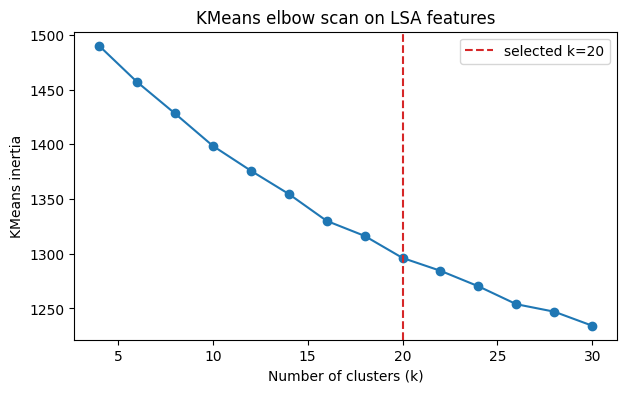

20

In [13]:
k_values = list(range(4, 31, 2))
inertias = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(lsa_embeddings)
    inertias.append(model.inertia_)

knee = KneeLocator(k_values, inertias, curve="convex", direction="decreasing")
best_k = int(knee.knee or 12)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_values, inertias, marker="o")
ax.axvline(best_k, color="tab:red", linestyle="--", label=f"selected k={best_k}")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("KMeans inertia")
ax.set_title("KMeans elbow scan on LSA features")
ax.legend()
plt.show()

best_k

In [14]:
kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=20)
kmeans_labels = kmeans_model.fit_predict(lsa_embeddings)
np.save(KMEANS_LABELS_CACHE, kmeans_labels)

ward_model = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
ward_labels = ward_model.fit_predict(lsa_embeddings)
np.save(WARD_LABELS_CACHE, ward_labels)

hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=30, min_samples=10, metric="euclidean")
hdbscan_labels = hdbscan_model.fit_predict(lsa_embeddings)
np.save(HDBSCAN_LABELS_CACHE, hdbscan_labels)

cluster_size_table(kmeans_labels)

,cluster,paper_count,share
0,2,185,0.100108
1,4,155,0.083874
2,3,143,0.077381
3,8,130,0.070346
4,13,128,0.069264
5,15,124,0.067100
6,0,118,0.063853
7,11,101,0.054654
8,5,93,0.050325
9,12,80,0.043290


In [15]:
metrics = []
for method, labels in [
    ("KMeans", kmeans_labels),
    ("Ward agglomerative", ward_labels),
    ("HDBSCAN", hdbscan_labels),
]:
    row = {"method": method}
    row.update(evaluate_labels(lsa_embeddings, labels))
    metrics.append(row)

clustering_results = pd.DataFrame(metrics).sort_values(
    ["silhouette", "davies_bouldin"],
    ascending=[False, True],
)

with CLUSTERING_CACHE.open("w") as handle:
    json.dump(clustering_results.to_dict(orient="records"), handle, indent=2)

clustering_results

,method,n_clusters,n_scored,outlier_fraction,silhouette,davies_bouldin,calinski_harabasz
2,HDBSCAN,2,269,0.854437,0.092882,4.232851,14.834460
0,KMeans,20,1848,0.000000,0.088108,3.700498,20.858453
1,Ward agglomerative,20,1848,0.000000,0.036092,4.009472,16.181321


In [16]:
hdbscan_cluster_sizes = cluster_size_table(hdbscan_labels)
hdbscan_cluster_sizes

,cluster,paper_count,share
0,-1,1579,0.854437
1,0,140,0.075758
2,1,129,0.069805
